## Lab 5 Mega Test — Set B (Logistic Regression Section)

**Topics from Lab 2, 3, 4:** preprocessing → visualization → logistic regression  
**Time:** 60–75 min | **Total:** 100 marks  
**Allowed:** pandas, numpy, matplotlib/seaborn, sklearn  
**Rule:** Write clear code with short comments. Show outputs (tables/plots).

# Dataset (provided)

**File:** `customer_logistic.csv`  
**Goal:** Predict **`buy`** (binary target: 0/1) using the given features (includes at least one categorical column and missing/sentinel values).


### Part A — Data Understanding + Cleaning + Encoding (Lab 2) [40 marks]

---

### Q1. Make a “column summary table” [12 marks]
After loading the dataset, create a new DataFrame called `summary` that has **one row per column** and these four columns:

- `column_name`
- `data_type`
- `missing_count`
- `missing_percent`

Then display `summary`.

*(Hint: missing percent = missing_count / total_rows × 100)*


### Q2. Clean missing / wrong values [16 marks]
This dataset contains missing values and may contain wrong placeholder values like `-99999`, `"NA"`, `"?"`.

Do the following:

1) Identify and replace all placeholder values with real missing values (`NaN`).  
2) For **numeric columns**, fill missing values using the **mean** of that column.  
3) For **categorical columns**, fill missing values using `"IDK"`.  
4) After cleaning, show missing values per column again to prove it worked.



### Q3. Compare two encoding methods (Label Encoding vs One-Hot) [12 marks]
Choose **one** categorical column (example: `city` or `gender` or `plan` — pick any that exists in your dataset).

Do the following:

1) **Label Encoding**
- Convert that column into numbers using `LabelEncoder`.
- Show the mapping (category → number).  
- Show the first 5 encoded values.

2) **One-Hot Encoding**
- One-hot encode the same column using `get_dummies()`.
- Show the first 5 rows of the one-hot encoded columns.

3) **Short answer (2–3 lines)**
- Which encoding is **better for logistic regression** and why?

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('customer_logistic.csv')
df.head()

,age,income,time_spent,visits,gender,city,buy
0,43.0,97k,-99999.000000,2.0,female,Dhaka,0
1,34.0,66k,11.885847,0.0,female,Dhaka,0
2,45.0,46k,1.921230,5.0,female,Calgary,0
3,35.0,97k,10.974633,4.0,female,Edmonton,1
4,31.0,NaN,4.032673,3.0,female,Dhaka,0


In [50]:
summary = pd.DataFrame({
    'column_name': df.columns,
    'data_type': df.dtypes,
    'missing_count': df.isnull().sum().values,
    'missing_percent': (df.isnull().sum().values/len(df))*100
})
summary.head(10)

,column_name,data_type,missing_count,missing_percent
age,age,float64,8,3.636364
income,income,object,9,4.090909
time_spent,time_spent,float64,0,0.000000
visits,visits,float64,0,0.000000
gender,gender,object,0,0.000000
city,city,object,12,5.454545
buy,buy,int64,0,0.000000


In [51]:
df.replace([-99999, "NA", "?", "na"], np.nan, inplace=True)

In [52]:
import pandas as pd
import numpy as np

# Handle 'income' column first:
# Replace 'IDK' with NaN, as it should be a numeric column.
# This handles cases where 'IDK' might have been present initially or introduced by prior fillna if income was treated as categorical.
df['income'] = df['income'].replace('IDK', np.nan)
# Convert 'income' to string to use .str accessor, remove 'k', then convert to float.
df['income'] = df['income'].astype(str).str.replace('k', '', regex=False)
df['income'] = pd.to_numeric(df['income'], errors='coerce')

# Fill missing values for numeric columns (now including 'income')
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing values for categorical columns with "IDK"
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna("IDK", inplace=True)

df.isna().sum()

,0
age,0
income,0
time_spent,0
visits,0
gender,0
city,0
buy,0


In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['city'] = le.fit_transform(df['city'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
df['city'].head()

{'Calgary': np.int64(0), 'Dhaka': np.int64(1), 'Edmonton': np.int64(2), 'IDK': np.int64(3), 'Toronto': np.int64(4)}


,city
0,1
1,1
2,0
3,2
4,1


In [54]:
one_hot = pd.get_dummies(df['gender'],dtype=int)
one_hot.head(10)

,IDK,female,male
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,0,1
6,0,1,0
7,0,1,0
8,0,0,1
9,0,0,1


One-Hot Encoding is better for Logistic Regression because:

* Label Encoding creates artificial order between categories.

* Logistic Regression assumes numeric meaning in features.

* One-Hot Encoding prevents false ordinal relationships.

## Part B — Visualization + Simple Statistics (Lab 3) [25 marks]

### Q4. Class balance + bar chart [8 marks]
1) Show how many samples belong to class **0** and class **1** in the target column `buy`.  
2) Draw a **bar chart / count plot** of `buy` (class 0 vs class 1).  
   - Add a title and axis labels.


### Q5. Compare one feature for buy=0 vs buy=1 (two plots) [10 marks]
Pick **one numeric feature** (example: `age`, `income`, `time_spent`, `visits` — choose any that exists).

Do BOTH:
1) Draw **two histograms** on the same figure (or side-by-side):
   - one for rows where `buy = 0`
   - one for rows where `buy = 1`
2) Write **2–3 lines** explaining what you see:
   - which class tends to have higher values?
   - does this feature look useful for prediction?

### Q6. Scatter plot (two numeric features) + simple conclusion [7 marks]
Pick **two numeric features** and draw a **scatter plot**:
- color points by `buy` (use different colors for 0 and 1)
- add title + axis labels

Then write **1–2 lines**:
- Do the two classes look clearly separated or mixed?

In [55]:
df['buy'].value_counts()

,count
buy,
0,145
1,75


<Axes: xlabel='buy', ylabel='count'>

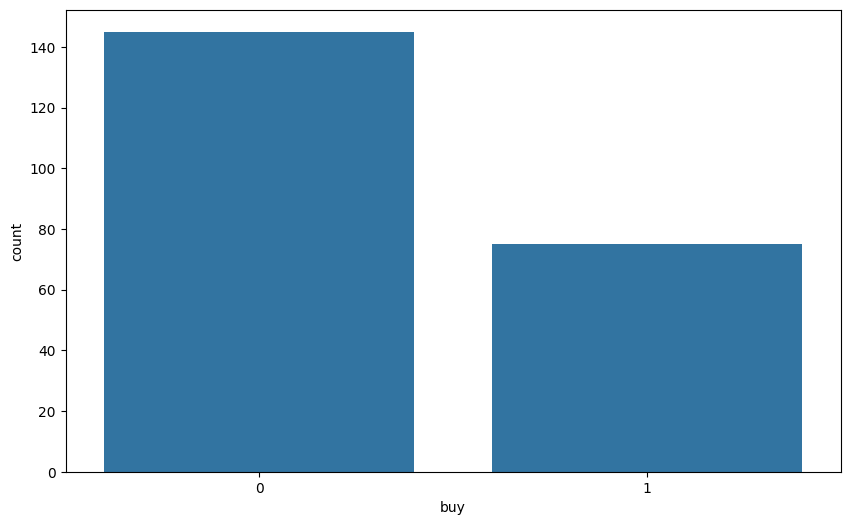

In [56]:
plt.figure(figsize=(10,6))
sns.countplot(x='buy', data=df)

<BarContainer object of 2 artists>

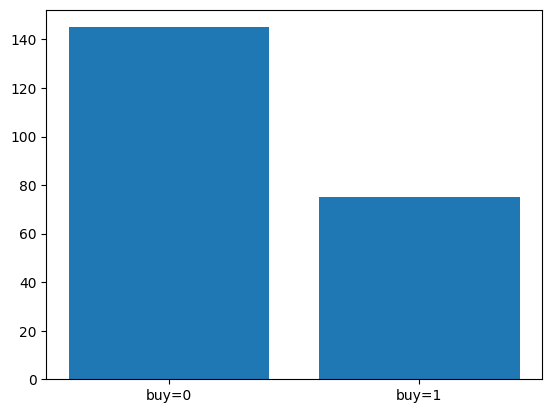

In [57]:
plt.bar(['buy=0', 'buy=1'], df['buy'].value_counts())

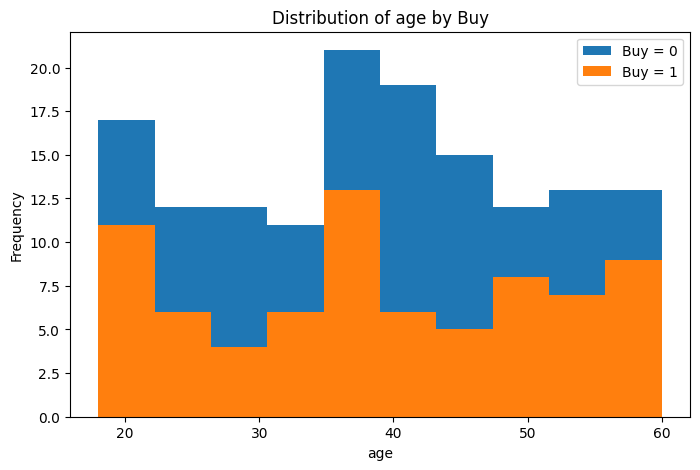

In [58]:
feature = [col for col in num_cols if col != "buy"][0]

plt.figure(figsize=(8,5))

plt.hist(df[df["buy"]==0][feature],label="Buy = 0")
plt.hist(df[df["buy"]==1][feature],label="Buy = 1")

plt.legend()
plt.title(f"Distribution of {feature} by Buy")
plt.xlabel(feature)
plt.ylabel("Frequency")
plt.show()

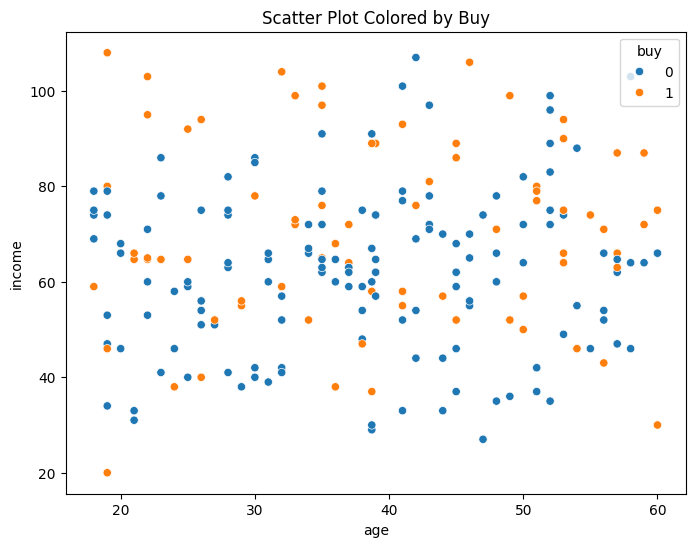

In [59]:
feature1 = [col for col in num_cols if col != "buy"][0]
feature2 = [col for col in num_cols if col != "buy"][1]

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x=feature1, y=feature2, hue="buy")

plt.title("Scatter Plot Colored by Buy")
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.show()

## Part C — Logistic Regression Model (Lab 4) [35 marks]

### Q7. Prepare X and y + scaling [12 marks]
1) Create:
- `y` = the target column `buy`
- `X` = all other columns (input features)

2) Scale the numeric columns of `X` using **one** method:
- Min–Max scaling **OR**
- Standardization (z-score)

Add 1–2 short comment lines: why scaling helps logistic regression.


### Q8. Train Logistic Regression [13 marks]
1) Split the data into training and testing sets (80/20).  
2) Train a Logistic Regression model using the training set.  

### Q9. Test performance + one single sample prediction [10 marks]
1) Evaluate the model on the test set using:
- Accuracy

2) Take **one sample** from the test set and show:
- its input values  
- predicted class (0/1)  
- predicted probability of class 1  
- actual class (`buy`)

In [60]:
y = df['buy']

# One-hot encode the 'gender' column
gender_one_hot = pd.get_dummies(df['gender'], prefix='gender', dtype=int)

# Drop the original 'buy' and 'gender' columns from df and concatenate the one-hot encoded gender
X = pd.concat([df.drop(['buy', 'gender'], axis=1), gender_one_hot], axis=1)

In [61]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
ss = StandardScaler()
mm = MinMaxScaler()

In [62]:
X_ss= ss.fit_transform(X)
X_mm = mm.fit_transform(X)

In [63]:
from sklearn.model_selection import train_test_split as tts
x_train, x_test, y_train, y_test = tts(X_mm, y, test_size=0.2, random_state=42)

In [64]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [65]:
lr.score(x_test, y_test)

0.6818181818181818

In [66]:
sample = x_test[0].reshape(1, -1)

pred_class = lr.predict(sample)
pred_prob = lr.predict_proba(sample)[0][1]
actual_class = y_test.iloc[0]

print("Input values:", x_test[0])
print("Predicted class:", pred_class[0])
print("Predicted probability of class 1:", pred_prob)
print("Actual class:", actual_class)

Input values: [0.71428571 0.57954545 0.52379981 0.11111111 0.5        0.
 1.         0.        ]
Predicted class: 0
Predicted probability of class 1: 0.35740832074888346
Actual class: 1


## Submission
Submit notebook as: **`Lab5_SetA_Name_ID_Section.ipynb`**  
Notebook must run from top to bottom without errors.